# Hungarian Real Estate Data Analysis

Exploring ~220K property listings and ~9M historical price records using **pandas**.

**Techniques**: `.str` accessor · `pipe` · `value_counts` · `groupby + agg` · `groupby + apply` · `pivot_table` · `merge` · `rolling`

**Data**: scraped from [ingatlan.com](https://ingatlan.com) — Hungarian real estate market.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.float_format", "{:.1f}".format)
pd.set_option("display.max_columns", 20)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 100, "font.size": 11})

## Data Loading

Toggle `USE_REMOTE` to switch between local files and remote URLs.

In [2]:
USE_REMOTE = False

SOURCES = {
    "details": {
        "local": "/mnt/data/synced/data/standalone/ingatlan/ingatlan-details.parquet",
        "remote": "https://share.borza.cc/ingatlan-details.parquet",
    },
    "listings": {
        "local": "/mnt/data/synced/data/standalone/ingatlan/ingatlan-listings.parquet",
        "remote": "https://share.borza.cc/ingatlan-listings.parquet",
    },
}


def load_dataset(name: str, use_remote: bool = USE_REMOTE) -> pd.DataFrame:
    return pd.read_parquet(SOURCES[name]["remote" if use_remote else "local"])


details = load_dataset("details")
listings = load_dataset("listings")

print(f"details:  {details.shape[0]:,} rows x {details.shape[1]} columns")
print(f"listings: {listings.shape[0]:,} rows x {listings.shape[1]} columns")
details.head(3)

details:  221,078 rows x 7 columns
listings: 9,130,075 rows x 3 columns


,loc,city,price,m2,rooms,balcony,id
0,"IX. kerület, Lónyay utca",Budapest,498862,95,3,,7065343
1,"Gárdony, Agárd",Gárdony,120000,25,1 fél,,33544237
2,"VI. kerület, Hajós utca",Budapest,306992,41,1,,32889588


In [3]:
listings.head(3)

,id,day,price
0,576781,2025-06-21,362466
1,576781,2025-05-22,362340
2,576781,2025-07-31,358893


## 1. Feature Engineering with `.pipe` and `.str`

Build a clean, enriched dataframe through a functional pipeline:
- **`.str.extract()`** — pull the Budapest district (`IX. kerület`) from the free-text `loc` field
- **`.str.replace()` + `pd.to_numeric`** — parse `'2 fél'` → `2.5`, `'3'` → `3.0`
- **`.str.extract()` again** — classify the street type (`utca`, `út`, `tér`, ...)
- **`pipe`** — compose all transformations without intermediate variables

In [11]:
def extract_district(df: pd.DataFrame) -> pd.DataFrame:
    """Extract Budapest district label (e.g. 'VIII. kerület') from the loc field."""
    return df.assign(
        district=df["loc"].str.extract(r"\b([IVX]+\.\s*kerület)\b", expand=False)
    )


def parse_rooms(df: pd.DataFrame) -> pd.DataFrame:
    """Convert '2 fél' -> 2.5, '3' -> 3.0; unparseable -> NaN."""
    return df.assign(
        rooms_num=(
            df["rooms"]
            .str.replace(" fél", ".5", regex=False)
            .pipe(pd.to_numeric, errors="coerce")
        )
    )


def add_price_per_m2(df: pd.DataFrame) -> pd.DataFrame:
    return df.assign(price_per_m2=(df["price"] / df["m2"]).round(1))


def flag_balcony(df: pd.DataFrame) -> pd.DataFrame:
    return df.assign(has_balcony=df["balcony"].notna())


def extract_street_type(df: pd.DataFrame) -> pd.DataFrame:
    """Extract street type as the last word of the loc field (.str chaining showcase)."""
    return df.assign(
        street_type=df["loc"].str.lower().str.split().str[-1].str.rstrip(".,")
    )


enriched = (
    details.pipe(extract_district)
    .pipe(parse_rooms)
    .pipe(add_price_per_m2)
    .pipe(flag_balcony)
    .pipe(extract_street_type)
)

enriched[
    [
        "loc",
        "district",
        "street_type",
        "rooms",
        "rooms_num",
        "price_per_m2",
        "has_balcony",
    ]
].head(6)

,loc,district,street_type,rooms,rooms_num,price_per_m2,has_balcony
0,"IX. kerület, Lónyay utca",IX. kerület,utca,3,3.0,5251.2,True
1,"Gárdony, Agárd",NaN,agárd,1 fél,1.5,4800.0,True
2,"VI. kerület, Hajós utca",VI. kerület,utca,1,1.0,7487.6,True
3,"II. kerület, Török utca",II. kerület,utca,3,3.0,3480.0,True
4,"V. kerület, Vörösmarty tér",V. kerület,tér,6,6.0,6292.7,True
5,"XII. kerület, Kissvábhegy",XII. kerület,kissvábhegy,1 + 1 fél,NaN,5869.6,True


In [12]:
enriched["district"].value_counts()

district
XIII. kerület     21274
XI. kerület       15414
IX. kerület       11645
VI. kerület       11395
VIII. kerület     10658
XIV. kerület      10117
V. kerület         9752
II. kerület        9563
VII. kerület       9486
III. kerület       8041
XII. kerület       5826
I. kerület         4334
X. kerület         2956
IV. kerület        2713
XVIII. kerület     1645
XV. kerület        1505
XVI. kerület       1494
XIX. kerület       1463
XXI. kerület       1388
XX. kerület        1332
XXII. kerület       931
XVII. kerület       833
XXIII. kerület      226
Name: count, dtype: int64

## 2. Distributions with `value_counts`

In [14]:
top_cities = (
    enriched["city"]
    .value_counts()
    .head(20)
    .rename_axis("city")
    .reset_index(name="listings")
    .assign(share_pct=lambda df: (df["listings"] / df["listings"].sum() * 100).round(2))
)

(
    top_cities.style.background_gradient(cmap="Blues", subset=["listings"])
    .bar(subset=["share_pct"], color="#aec6cf", vmin=0)
    .format({"listings": "{:,}", "share_pct": "{:.2f}%"})
    .set_caption("Top 20 cities by listing count")
)

,city,listings,share_pct
0,Budapest,"145,123",72.45%
1,Debrecen,"13,460",6.72%
2,Pécs,"6,894",3.44%
3,Szeged,"4,972",2.48%
4,Győr,"4,815",2.40%
5,Miskolc,"3,458",1.73%
6,Székesfehérvár,"2,908",1.45%
7,Nyíregyháza,"2,855",1.43%
8,Kecskemét,"2,496",1.25%
9,Veszprém,"1,659",0.83%


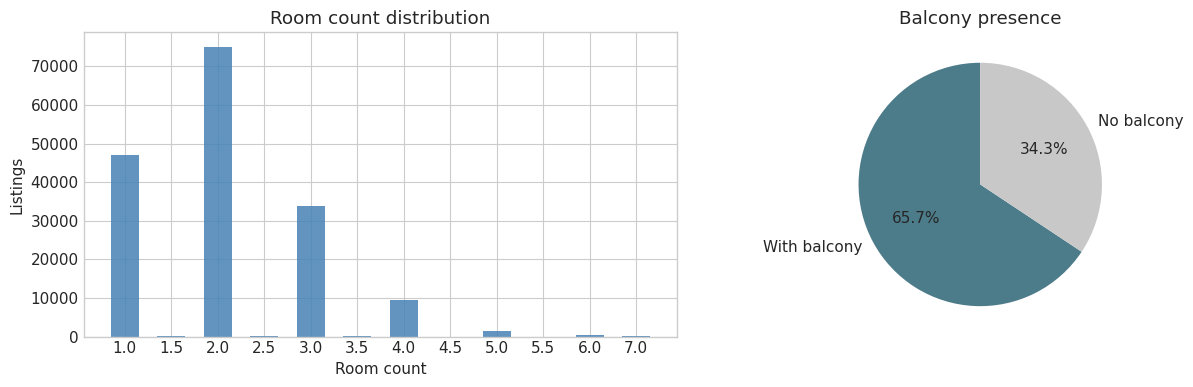

In [7]:
room_counts = (
    enriched["rooms_num"]
    .dropna()
    .value_counts()
    .sort_index()
    .loc[lambda s: s.index <= 7]
)

balcony_share = (
    enriched["has_balcony"]
    .map({True: "With balcony", False: "No balcony"})
    .value_counts()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(
    room_counts.index.astype(str),
    room_counts.values,
    color="steelblue",
    width=0.6,
    alpha=0.85,
)
axes[0].set_xlabel("Room count")
axes[0].set_ylabel("Listings")
axes[0].set_title("Room count distribution")

axes[1].pie(
    balcony_share,
    labels=balcony_share.index,
    autopct="%1.1f%%",
    colors=["#4c7b8a", "#c8c8c8"],
    startangle=90,
)
axes[1].set_title("Balcony presence")

plt.tight_layout()
plt.show()

## 3. Price Statistics with `groupby + agg`

Aggregate price-per-m2 statistics across cities — and across Budapest districts separately.

In [15]:
def city_price_summary(df: pd.DataFrame, min_listings: int = 200) -> pd.DataFrame:
    return (
        df.groupby("city")["price_per_m2"]
        .agg(
            listings="count",
            median="median",
            mean="mean",
            p25=lambda x: x.quantile(0.25),
            p75=lambda x: x.quantile(0.75),
            std="std",
        )
        .query("listings >= @min_listings")
        .sort_values("median", ascending=False)
        .round(0)
        .astype({"listings": int})
        .head(20)
    )


city_stats = enriched.pipe(city_price_summary)

(
    city_stats.style.background_gradient(cmap="RdYlGn_r", subset=["median", "mean"])
    .background_gradient(cmap="Blues", subset=["listings"])
    .format(
        {
            "listings": "{:,}",
            "median": "{:.0f}",
            "mean": "{:.0f}",
            "p25": "{:.0f}",
            "p75": "{:.0f}",
            "std": "{:.0f}",
        }
    )
    .set_caption(
        "Price per m\u00b2 (eFt) by city \u2014 top 20 most expensive (min. 200 listings)"
    )
)

,listings,median,mean,p25,p75,std
city,,,,,,
Budapest,"145,123",5263,27127,4348,6400,2925968
Biatorbágy,263,4600,20063,3804,5227,250671
Dunakeszi,889,4464,13958,3846,5000,199577
Balatonfüred,562,4456,10619,3625,5551,135397
Budaörs,660,4417,37781,3722,5209,461731
Debrecen,"13,460",4400,16036,3667,5429,253090
Érd,798,4147,22025,3509,4920,258142
Szentendre,426,4000,13609,3527,4806,193599
Budakeszi,221,3810,3989,3067,4400,1509


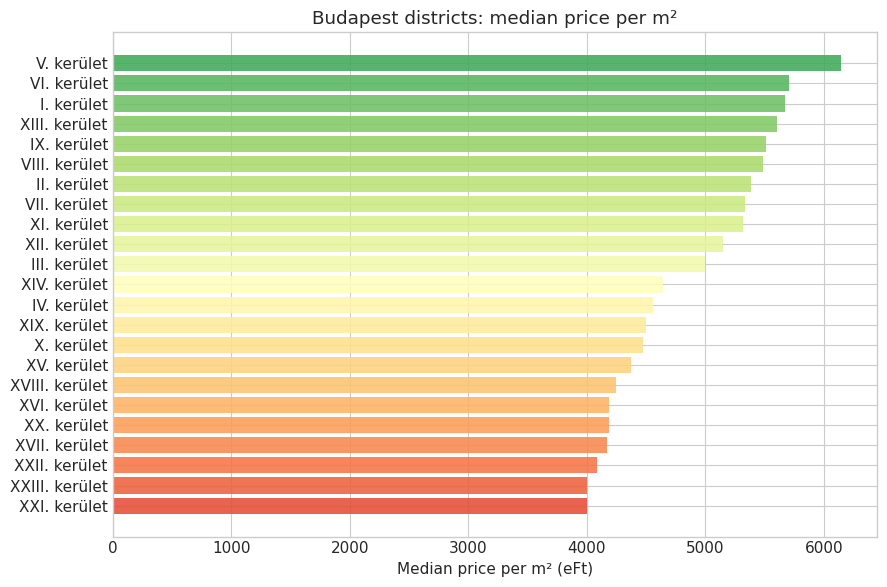

In [16]:
district_medians = (
    enriched.loc[enriched["district"].notna()]
    .groupby("district")["price_per_m2"]
    .median()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(district_medians))[::-1])
ax.barh(district_medians.index, district_medians.values, color=colors, alpha=0.88)
ax.set_xlabel("Median price per m\u00b2 (eFt)")
ax.set_title("Budapest districts: median price per m\u00b2")
plt.tight_layout()
plt.show()

## 4. Group Profiles with `groupby + apply`

`apply` lets us return an arbitrary `Series` per group — here we compute a full profile
(count, median price/m\u00b2, typical size, balcony share) for every district × room-count combination.

In [17]:
def district_room_profile(group: pd.DataFrame) -> pd.Series:
    return pd.Series(
        {
            "listings": len(group),
            "median_ppm2": group["price_per_m2"].median(),
            "median_m2": group["m2"].median(),
            "balcony_pct": group["has_balcony"].mean() * 100,
        }
    )


district_profiles = (
    enriched.loc[enriched["district"].notna() & enriched["rooms_num"].between(1, 5)]
    .groupby(["district", "rooms_num"])
    .apply(district_room_profile, include_groups=False)
    .round(1)
    .astype({"listings": int})
)

district_profiles.head(12)

listings  median_ppm2  median_m2  balcony_pct
district    rooms_num                                               
I. kerület  1.0             893       6129.0       34.0         47.8
            1.5               4      10141.0       14.0         25.0
            2.0            1235       5400.0       55.0         63.2
            2.5               1       2155.2       58.0          0.0
            3.0             860       5687.4       81.0         72.6
            4.0             295       6654.2      119.0         75.3
            5.0              26       7104.6      145.0         76.9
II. kerület 1.0            1316       5789.5       34.0         55.2
            1.5               3       7272.7       11.0         66.7
            2.0            2261       5000.0       56.0         76.8
            2.5               8       5300.5       49.0         75.0
            3.0            2004       5538.5       85.0         84.0

In [18]:
# Show the most expensive district profiles
(
    district_profiles.query("listings >= 10")
    .nlargest(15, "median_ppm2")
    .style.background_gradient(cmap="RdYlGn_r", subset=["median_ppm2"])
    .background_gradient(cmap="Greens", subset=["balcony_pct"])
    .background_gradient(cmap="Blues", subset=["listings"])
    .format(
        {
            "listings": "{:,}",
            "median_ppm2": "{:.0f}",
            "median_m2": "{:.0f}",
            "balcony_pct": "{:.1f}%",
        }
    )
    .set_caption("Top 15 district x room-count combinations by median price/m\u00b2")
)

,,listings,median_ppm2,median_m2,balcony_pct
district,rooms_num,,,,
IX. kerület,1.500000,11,12000,8,36.4%
XIII. kerület,1.500000,19,10000,11,42.1%
VI. kerület,1.500000,11,8605,17,36.4%
VII. kerület,1.500000,10,8583,23,20.0%
IV. kerület,5.000000,11,7753,115,100.0%
VIII. kerület,1.500000,19,7500,15,42.1%
V. kerület,5.000000,131,7178,160,61.8%
I. kerület,5.000000,26,7105,145,76.9%
V. kerület,4.000000,740,7034,126,61.1%


## 5. Cross-tabulation with `pivot_table`

A pivot table as a price heatmap: room count on the index, district on the columns.

In [19]:
def build_ppm2_pivot(df: pd.DataFrame) -> pd.DataFrame:
    top_districts = (
        df.loc[df["district"].notna()]
        .groupby("district")["price_per_m2"]
        .median()
        .nlargest(10)
        .index
    )
    return pd.pivot_table(
        df.loc[df["district"].isin(top_districts) & df["rooms_num"].between(1, 5)],
        values="price_per_m2",
        index="rooms_num",
        columns="district",
        aggfunc="median",
    ).round(0)


ppm2_pivot = enriched.pipe(build_ppm2_pivot)

(
    ppm2_pivot.style.background_gradient(cmap="RdYlGn_r", axis=None)
    .format("{:.0f}", na_rep="\u2014")
    .set_caption(
        "Median price per m\u00b2 (eFt) \u2014 room count \u00d7 district (top 10 districts)"
    )
)

district,I. kerület,II. kerület,IX. kerület,V. kerület,VI. kerület,VII. kerület,VIII. kerület,XI. kerület,XII. kerület,XIII. kerület
rooms_num,,,,,,,,,,
1.000000,6129,5790,6000,6379,6385,6034,6000,5833,5556,5833
1.500000,10141,7273,12000,7248,8605,8583,7500,7059,6873,10000
2.000000,5400,5000,5385,5698,5385,4906,5435,5128,4851,5697
2.500000,2155,5300,6102,6586,6385,5600,5000,4528,5333,6021
3.000000,5687,5538,5044,6400,5576,4688,4984,5441,5000,5645
3.500000,—,5642,7852,6277,4139,4094,3676,4911,—,3868
4.000000,6654,6646,5333,7034,6203,5000,4268,5795,6034,5910
4.500000,—,7106,6842,—,—,—,2812,—,—,—
5.000000,7105,5818,4419,7178,6491,5000,4792,6159,5932,5511


/tmp/ipykernel_2036345/1985841818.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


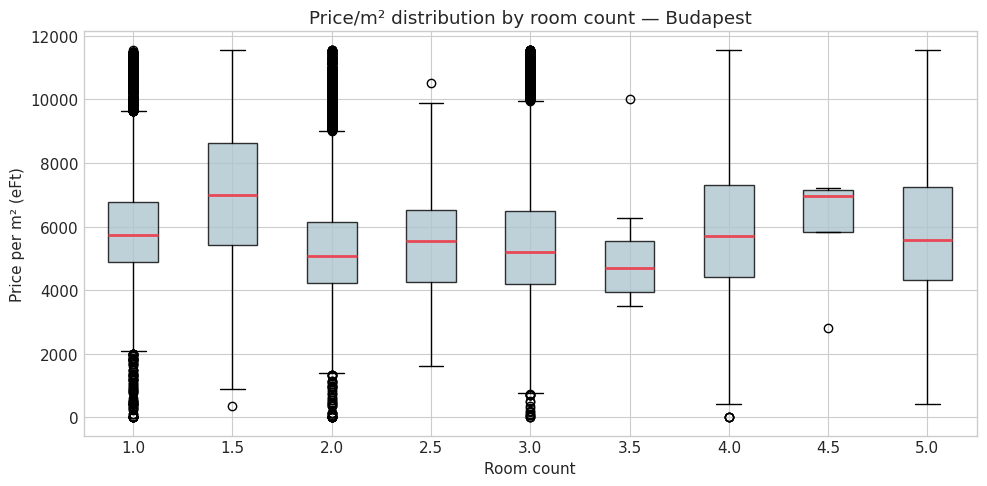

In [21]:
# Price/m2 distribution by room count — Budapest, clipped at 99th percentile
bp_data = enriched.loc[
    (enriched["city"] == "Budapest")
    & enriched["rooms_num"].between(1, 5)
    & (enriched["price_per_m2"] < enriched["price_per_m2"].quantile(0.99))
]

room_values = sorted(bp_data["rooms_num"].dropna().unique())
groups = [
    bp_data.loc[bp_data["rooms_num"] == r, "price_per_m2"].values for r in room_values
]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(
    groups,
    labels=[str(r) for r in room_values],
    patch_artist=True,
    medianprops=dict(color="#e84855", lw=2),
)
for patch in bp["boxes"]:
    patch.set_facecolor("#aec6cf")
    patch.set_alpha(0.8)
ax.set_xlabel("Room count")
ax.set_ylabel("Price per m\u00b2 (eFt)")
ax.set_title("Price/m\u00b2 distribution by room count \u2014 Budapest")
plt.tight_layout()
plt.show()

## 6. Enrichment via `merge`

Join the static property details with a summary of their listing history:
first price, latest price, total observations, and the percentage price change.

In [22]:
def summarise_listing_history(listings: pd.DataFrame) -> pd.DataFrame:
    """First/last price and observation count per property id."""
    return (
        listings.sort_values("day")
        .groupby("id")
        .agg(
            first_price=("price", "first"),
            last_price=("price", "last"),
            first_seen=("day", "first"),
            last_seen=("day", "last"),
            n_obs=("price", "count"),
        )
        .reset_index()
        .assign(
            price_change_pct=lambda df: (
                (df["last_price"] - df["first_price"]) / df["first_price"] * 100
            ).round(1)
        )
    )


history = summarise_listing_history(listings)

enriched_full = enriched.merge(history, on="id", how="left")

enriched_full[
    [
        "city",
        "m2",
        "rooms_num",
        "price_per_m2",
        "first_seen",
        "last_seen",
        "n_obs",
        "price_change_pct",
    ]
].head(5)

,city,m2,rooms_num,price_per_m2,first_seen,last_seen,n_obs,price_change_pct
0,Budapest,95,3.0,5251.2,2023-10-20,2024-05-23,144,-14.9
1,Gárdony,25,1.5,4800.0,2023-10-20,2026-02-19,484,25.0
2,Budapest,41,1.0,7487.6,2023-10-20,2024-03-11,89,2.8
3,Budapest,125,3.0,3480.0,2023-10-20,2024-07-08,95,0.0
4,Budapest,205,6.0,6292.7,2023-10-20,2024-06-21,171,0.0


In [23]:
(
    enriched_full.query("n_obs >= 5")
    .nlargest(15, "n_obs")[
        [
            "loc",
            "city",
            "m2",
            "rooms_num",
            "price_per_m2",
            "n_obs",
            "price_change_pct",
            "first_seen",
            "last_seen",
        ]
    ]
    .style.background_gradient(cmap="Blues", subset=["n_obs"])
    .background_gradient(cmap="RdYlGn", subset=["price_change_pct"])
    .format(
        {
            "price_per_m2": "{:.0f}",
            "rooms_num": "{:.1f}",
            "n_obs": "{:.0f}",
            "price_change_pct": "{:+.1f}%",
        }
    )
    .set_caption("Properties with most price observations")
)

,loc,city,m2,rooms_num,price_per_m2,n_obs,price_change_pct,first_seen,last_seen
4155,"XVII. kerület, Pesti út 237/l",Budapest,12,1.0,12917,733,+9.7%,2023-10-20 00:00:00,2026-02-19 00:00:00
14657,"V. kerület, Váci utca 19-21.",Budapest,82,3.0,4557,701,+23.9%,2023-11-07 00:00:00,2026-02-19 00:00:00
5265,"II. kerület, Szemlőhegy",Budapest,183,5.0,8388,692,-1.6%,2023-10-20 00:00:00,2026-02-19 00:00:00
5327,"I. kerület, Vár",Budapest,86,2.0,7586,682,+15.8%,2023-10-20 00:00:00,2026-02-19 00:00:00
2669,"VI. kerület, Andrássy út",Budapest,100,1.0,6524,681,-13.1%,2023-10-20 00:00:00,2026-02-19 00:00:00
6772,"V. kerület, Vigadó tér 5.",Budapest,70,nan,13929,681,-50.8%,2023-10-20 00:00:00,2026-02-19 00:00:00
9121,"Gyöngyös, Móricz Zsigmond utca 4.",Gyöngyös,115,3.0,1304,681,+0.0%,2023-10-20 00:00:00,2026-02-19 00:00:00
9804,"V. kerület, Belgrád rakpart",Budapest,106,4.0,4906,680,-28.7%,2023-10-20 00:00:00,2026-02-19 00:00:00
9137,"II. kerület, Törökvész",Budapest,105,3.0,5482,676,-1.6%,2023-10-20 00:00:00,2026-02-19 00:00:00
9550,"Göd, Alsógöd",Göd,140,5.0,8571,675,+0.0%,2023-10-20 00:00:00,2026-02-19 00:00:00


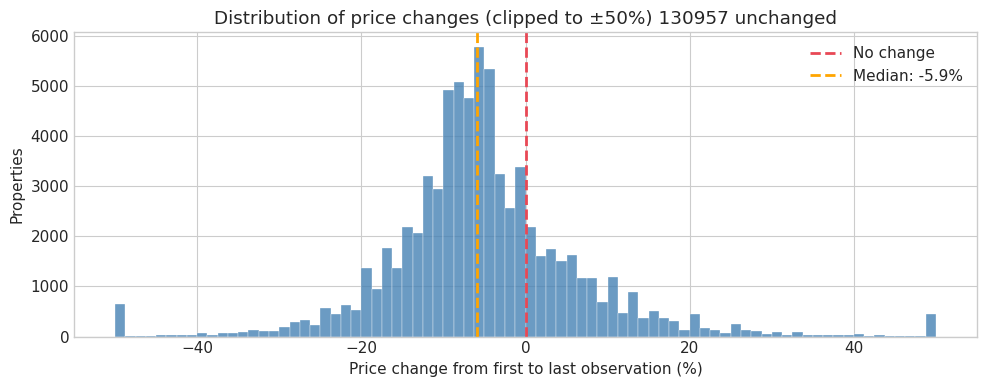

In [24]:
# Price change distribution — discount vs appreciation
changes = (
    enriched_full.loc[lambda df: (df["n_obs"] >= 3) & (df["price_change_pct"] != 0)][
        "price_change_pct"
    ]
    .dropna()
    .clip(-50, 50)
)

n_unchanged = (
    enriched_full.loc[lambda df: df["n_obs"] >= 3, "price_change_pct"]
    .pipe(lambda s: s == 0)
    .sum()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(
    changes, bins=80, color="steelblue", alpha=0.8, edgecolor="white", linewidth=0.3
)
ax.axvline(0, color="#e84855", lw=2, linestyle="--", label="No change")
ax.axvline(
    changes.median(),
    color="orange",
    lw=2,
    linestyle="--",
    label=f"Median: {changes.median():+.1f}%",
)
ax.set_xlabel("Price change from first to last observation (%)")
ax.set_ylabel("Properties")
ax.set_title(
    f"Distribution of price changes (clipped to \u00b150%) {n_unchanged} unchanged"
)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Market Price Trend with `rolling`

Aggregate to a daily median, then apply 30- and 90-day rolling averages to smooth out noise.

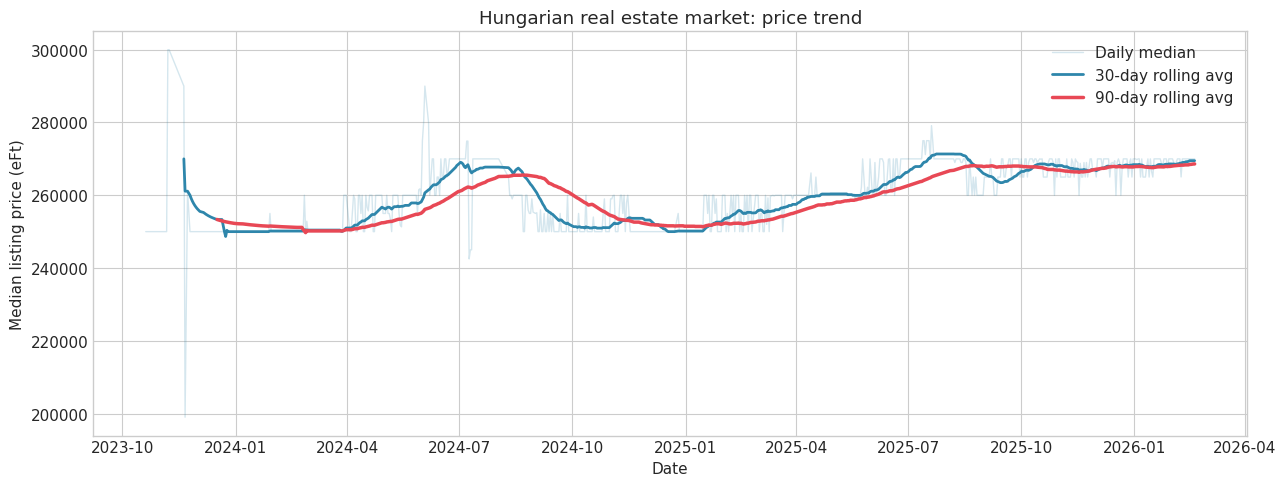

In [25]:
def market_price_trend(listings: pd.DataFrame) -> pd.DataFrame:
    """Daily median listing price with 30- and 90-day rolling averages."""
    return (
        listings.groupby("day")["price"]
        .median()
        .reset_index(name="daily_median")
        .sort_values("day")
        .assign(
            rolling_30d=lambda df: df["daily_median"].rolling(30, min_periods=7).mean(),
            rolling_90d=lambda df: df["daily_median"]
            .rolling(90, min_periods=30)
            .mean(),
        )
    )


trend = market_price_trend(listings)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(
    trend["day"],
    trend["daily_median"],
    alpha=0.2,
    color="#2e86ab",
    lw=1,
    label="Daily median",
)
ax.plot(
    trend["day"],
    trend["rolling_30d"],
    color="#2e86ab",
    lw=2,
    label="30-day rolling avg",
)
ax.plot(
    trend["day"],
    trend["rolling_90d"],
    color="#e84855",
    lw=2.5,
    label="90-day rolling avg",
)
ax.set_xlabel("Date")
ax.set_ylabel("Median listing price (eFt)")
ax.set_title("Hungarian real estate market: price trend")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Per-City Trends with `groupby + apply` + `rolling`

Merge listings with city information, compute a daily median per city,
then use `groupby + apply` to add a rolling average inside each city group.

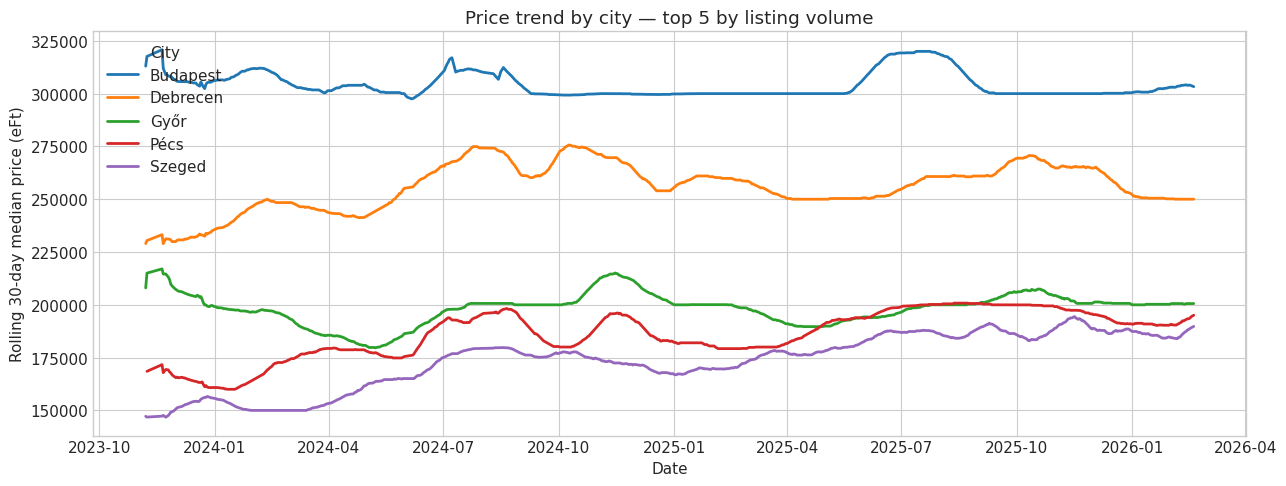

In [20]:
def add_rolling_30d(group: pd.DataFrame) -> pd.DataFrame:
    """Add 30-day rolling mean price column within a single city group."""
    return group.assign(rolling_30d=group["price"].rolling(30, min_periods=5).mean())


top5_cities = details["city"].value_counts().head(5).index
top5_ids = set(details.loc[details["city"].isin(top5_cities), "id"])

city_trends = (
    listings.loc[listings["id"].isin(top5_ids)]
    .merge(details[["id", "city"]], on="id")
    .groupby(["city", "day"])["price"]
    .median()
    .reset_index()
    .sort_values(["city", "day"])
    .groupby("city", group_keys=True)
    .apply(add_rolling_30d)
)

fig, ax = plt.subplots(figsize=(13, 5))
for city, group in city_trends.groupby("city"):
    ax.plot(group["day"], group["rolling_30d"], label=city, lw=2)
ax.set_xlabel("Date")
ax.set_ylabel("Rolling 30-day median price (eFt)")
ax.set_title("Price trend by city \u2014 top 5 by listing volume")
ax.legend(title="City")
plt.tight_layout()
plt.show()